<a href="https://colab.research.google.com/github/deekshitha29082006/WPT/blob/main/miniproject1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Records
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode

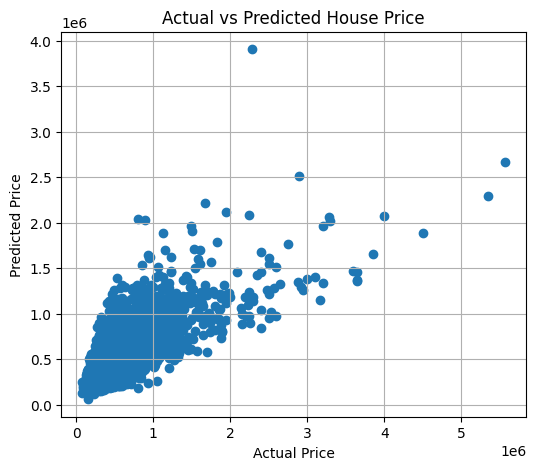

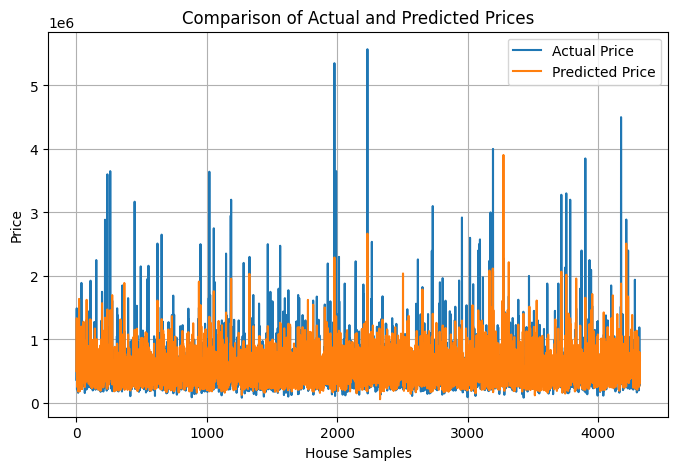

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv("/content/house_data.csv")
print("First 5 Records")
print(df.head())
print("\nMissing Values")
print(df.isnull().sum())
X = df[["sqft_living", "bedrooms", "bathrooms", "floors"]]
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred.round(2)
})
print("\nActual vs Predicted Price")
print(result.head(10))
print("\nModel Performance")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :", r2_score(y_test, y_pred))
new_house = pd.DataFrame({
    "sqft_living": [6000],
    "bedrooms": [3],
    "bathrooms": [2],
    "floors": [2]
})
prediction = model.predict(new_house)
print("\nPredicted Price for New House:", prediction[0])
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.grid(True)
plt.show()
plt.figure(figsize=(8,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.xlabel("House Samples")
plt.ylabel("Price")
plt.title("Comparison of Actual and Predicted Prices")
plt.legend()
plt.grid(True)
plt.show()